<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

L'objectif de ce notebook est d’analyser le stock et les ventes du site Bottleneck.

Dans une première partie, nous procéderons au nettoyage des données au format Excel issues de différentes sources. Ces sources peuvent être internes, comme ERP et Liaison, ou externes, via le site de Bottleneck (Web).

Nous examinerons ces données sous différents aspects :
+ la complétude,
+ la duplication,
+ la conformité au type et au format,
+ la cohérence logique,
+ la cohérence inter-table.

Ensuite, nous réaliserons une analyse univariée de chaque variable afin d’évaluer la profitabilité des activités du site, à l’aide des calculs suivants :

+ Chiffre d'affaires (CA),
+ Quantité de stock,
+ Valeur du stock,
+ Rotation du stock,
+ Taux de marge.

Enfin, nous aborderons brièvement l’analyse bivariée pour étudier les relations entre ces différentes informations.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [75]:
#Importation de la librairie Pandas
import pandas as pd
#Importation de la librairie numpy
import numpy as np
#Importation de la librairie matplotlib
import matplotlib.pyplot as plt
#Importation de la librairie seaborn
import seaborn as sns
#Impoartation de la librairie scipy
import scipy.stats as st
#Importation de la librairie statsmodels
import statsmodels.api as sm
#Importation de la librairie plotly express
import plotly.express as px

In [76]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium

pd.set_option('display.max_columns', None) # ou None
pd.set_option('display.max_rows', 1000)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>


In [77]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [78]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [79]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

#La nature des données dans chacune des colonnes
print("La nature des données dans chacune des colonnes : \n{}".format(df_erp.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
print("Le nombre de valeurs présentes dans chacune des colones : \n{notna}".format( notna = df_erp.count()))

print(df_erp["product_id"].sum()) # Type int

Le tableau comporte 6 colonne(s)
La nature des données dans chacune des colonnes : 
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
Le nombre de valeurs présentes dans chacune des colones : 
product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64
4259143


In [80]:
#Afficher les 5 premières lignes de la table
print(df_erp.head(5))

   product_id  onsale_web  price  stock_quantity stock_status  purchase_price
0        3847           1   24.2              16      instock           12.88
1        3849           1   34.3              10      instock           17.54
2        3850           1   20.8               0   outofstock           10.64
3        4032           1   14.1              26      instock            6.92
4        4039           1   46.0               3   outofstock           23.77


In [81]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
print("Il y a {erp_doublons} doublons dans la colonne product_id".format(erp_doublons = df_erp.duplicated(subset=["product_id"]).sum()))

Il y a 0 doublons dans la colonne product_id


In [82]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Les valeurs distinctes de la colonne stock_status sont : {}".format(df_erp["stock_status"].unique()))

#À quelle(s) autre(s) colonne(s) sont-elles liées ?

Les valeurs distinctes de la colonne stock_status sont : ['instock' 'outofstock']


La colonne "stock_status" est liée à la colonne "stock_quantity".

In [83]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: 'outofstock' if x == 0 else 'instock')


In [84]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:

#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
df_erp["stockTF"] = df_erp.apply(lambda df_erp: 1 if df_erp["stock_status"] == df_erp["stock_status_2"] else 0, axis=1)
#True vaut 1 et False 0

print("Le nombre de status identique entre 2 colonnes de status est de {id}, alors qu'il y a {ligne} articles au total.".format(id = df_erp["stockTF"].sum(), ligne = df_erp.shape[0]))
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

Le nombre de status identique entre 2 colonnes de status est de 821, alors qu'il y a 825 articles au total.


In [85]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3  # Je ne sais pas comment l'exploiter ???

print("Lignes incohérentes sont les suivantes :\n{}".format(df_erp.loc[df_erp["stockTF"]==0]))

Lignes incohérentes sont les suivantes :
     product_id  onsale_web  price  stock_quantity stock_status  \
4          4039           1   46.0               3   outofstock   
398        4885           1   18.7               0      instock   
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  stockTF  
4             23.77        instock        0  
398            9.66     outofstock        0  
449            4.96        instock        0  
573           22.30        instock        0  


In [86]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp["stockTF"]==0, "stock_status"] = df_erp.loc[df_erp["stockTF"]==0,"stock_status_2"]

#Verification en utilisant le même code que plus haut pour afficher les problemes
df_erp["stockTF"] = df_erp["stock_status"] == df_erp["stock_status_2"]
df_erp["stockTF"] = df_erp["stockTF"].apply(lambda x: 1 if x == True else 0)

print("Après la correction, le nombre de status identique entre 2 colonnes est de {}.".format(df_erp["stockTF"].sum()))

Après la correction, le nombre de status identique entre 2 colonnes est de 825.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [87]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp["price"].isna().sum())) #Saisir l'instruction manquante dans la fonction format

#Afficher le prix minimum de la colonne "price"
print("Le prix minimum est de {}".format(df_erp["price"].min()))

#Afficher le prix maximum de la colonne "price"
print("Le prix maximum est de {}".format(df_erp["price"].max()))

#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print("Le prix inférieurs à 0 de la colonne price est de {}".format(df_erp.loc[df_erp["price"]<0, "price"].count()))


Nombres d'article avec un prix non renseignés: 0
Le prix minimum est de -20.0
Le prix maximum est de 225.0
Le prix inférieurs à 0 de la colonne price est de 3


In [88]:
# Print les données négatives
print("Les produits de prix négatifs sont : \n{}".format(df_erp.loc[df_erp["price"]<0, ["product_id","price"]]))

Les produits de prix négatifs sont : 
     product_id  price
151        4233  -20.0
469        5017   -8.0
739        6594   -9.1


On peut faire la correction de la colonne "price" en supposant que les valeurs inférieures à 0 ont été saisie à la négation.

In [89]:
### Moi  - Correction
# Cette étape nécessite la vérification avec les équipes compétants, dans notre cas considèrer que c'est une faute
df_erp.loc[df_erp["price"]<0, "price"] = - df_erp.loc[df_erp["price"]<0, "price"]

print("La colonne \"price\" dont les valeurs sont inférieures à 0 sont de {}".format(df_erp.loc[df_erp["price"]<0, "price"].count()))

La colonne "price" dont les valeurs sont inférieures à 0 sont de 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [90]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("La quantité minimum de stock_quantity est de {}".format(df_erp["stock_quantity"].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("La quantité minimum de stock_quantity est de {}".format(df_erp["stock_quantity"].max()))

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print("Le prix inférieurs à 0 de la colonne stock_quantity est de {}".format(df_erp.loc[df_erp["stock_quantity"]<0, "stock_quantity"].count()))


La quantité minimum de stock_quantity est de -10
La quantité minimum de stock_quantity est de 145
Le prix inférieurs à 0 de la colonne stock_quantity est de 2


Anomalie : il existe des quantités de stock qui sont négatives.
On peut procéder à la correction comme pour les prix de vente.

In [91]:
### Moi - Correction
# Corriger l'erreur de stock_quantity
df_erp.loc[df_erp["stock_quantity"]<0, "stock_quantity"] = - df_erp.loc[df_erp["stock_quantity"]<0, "stock_quantity"]

print("Après la correction, la colonne \"stock_quantity\" inférieure à 0 est de {}".format(df_erp.loc[df_erp["stock_quantity"]<0, "stock_quantity"].count()))

Après la correction, la colonne "stock_quantity" inférieure à 0 est de 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [92]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].value_counts()

,count
onsale_web,
1,716
0,109


La colonne "onsale_web" contient deux valeurs : 1 signifie que l'article est vendu en ligne, et 0 indique le contraire.

Toutes les colonnes de cette base de données peuvent être conservées :
"produit_id", "price", "onsale_web", "stock_quantity", "stock_status", "purchase_price",
à l'exception de celles que nous avons produites.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [93]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'article avec un prix d'achat non renseignés: {}".format(df_erp["purchase_price"].isna().sum())) #Saisir l'instruction manquante dans la fonction format

#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix minimum de 'purchase_price' est de {}".format(df_erp["purchase_price"].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix maximum de 'purchase_price' est de {}".format(df_erp["purchase_price"].max()))



Nombres d'article avec un prix d'achat non renseignés: 0
Le prix minimum de 'purchase_price' est de 2.74
Le prix maximum de 'purchase_price' est de 137.81


Les valeurs me paraîent normales. Il n'y a donc pas de valeurs aberrantes.

In [94]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".

df_erp.drop(columns=["stock_status_2", "stockTF"], inplace=True)
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


Le traitement des données de l'ERP est terminé. Les colonnes à conserver sont : "produit_id", "price", "stock_quantity", "stock_status", et "purchase_price".

Les erreurs telles que "nullité", "unicité", "incohérence logique" et "type" ont été examinées pour toutes les colonnes.

Lors de cette phase exploratoire, nous avons analysé les données de l’ERP sous différents aspects. Nous pouvons conclure que les informations sont plutôt complètes dans ce fichier et qu’il n’existe pas de doublons. Cependant, nous avons relevé certaines incohérences entre les variables.

D'abord, ce sont les colonnes de "stock_status" et "stock_quantity". Par conséquent, on a modifié les valeurs de la colonne "stock_status" en fonction de la quantité en stock du produit.

Puis, c'est la colonne de "price". Dans la logique normale, il ne peut pas avoir des prix de produit négatif, mais c'est ce qui est observée dans ce cas (minimum est de -20). Dans ce cas là, il faut en réalité discuter avec l'équipe fournissant ces données, pour comprendre les anomalies. Mais, dans notre cas, on va plutôt considérer qu'il s'agit des erreurs humaines qui ont mis les prix de manière négatifs. Ainsi, nous avons corrigé les erreurs en les rendant positives.

De même manière pour la variable "stock_quantity" possèdant les valeurs inférieures à 0.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [95]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))

#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [96]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de {}".format(df_web.shape[1]))

#La nature des données dans chacune des colonnes
print("La nature des données dans chacune des colonnes : \n{}".format(df_web.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
print("Le nombre de valeurs présentes dans chaque colonne est comme suivant : \n{}".format(df_web.count()))

Le nombre de colonnes est de 29
La nature des données dans chacune des colonnes : 
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float

In [97]:
#Visualisation des valeurs de la colonne sku
print("Les valeurs de la colonne sku sont : {}".format(df_web["sku"].unique()))
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


Les valeurs de la colonne sku sont : [11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15

Il existe des valeurs qui sont en chaine de caractère. Ce sont les valeurs de sku qui sont égale aux ('13127-1', 'bon-cadeau-25-euros'). Ces deux identifiants sont de type différents.

In [98]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
df_web.loc[df_web["sku"].apply(lambda x: isinstance(x, str)), ["sku", "post_type"]]

,sku,post_type
272,13127-1,product
842,bon-cadeau-25-euros,attachment
1117,13127-1,attachment
1387,bon-cadeau-25-euros,product


In [99]:
#Identifier les lignes sans code articles
df_web[df_web["sku"].isna()].head(5)


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
df_web[~df_web["sku"].isna()].head(5)

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


Pour les articles identifiés, il existe des doublons. Les valeurs rensignées dans les colonnes pour chaque ligne de même sku ne sont pas les mêmes, notamment le type de postulation "post_type" sont différents. Il existe pour les mêmes sku, une ligne "product" et une autre "attachment".

In [101]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
df_web.duplicated(subset=["sku"]).sum()

print("Il reste {} doublons sans les identifiants NA.".format(df_web.loc[df_web.duplicated(subset = ["sku"]), "sku"].count()))


Il reste 714 doublons sans les identifiants NA.


In [102]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
web_nonCode = df_web[df_web["sku"].isna()]

#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
web_nonCode.info()

#3 - Que constatez-vous?
df_web.loc[df_web["sku"].isna() & df_web["post_title"].notna(), ["sku", "post_title"]]

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    0 non-null      object        
 1   virtual                85 non-null     int64         
 2   downloadable           85 non-null     int64         
 3   rating_count           85 non-null     int64         
 4   average_rating         2 non-null      float64       
 5   total_sales            2 non-null      float64       
 6   tax_status             2 non-null      object        
 7   tax_class              0 non-null      float64       
 8   post_author            2 non-null      float64       
 9   post_date              2 non-null      datetime64[ns]
 10  post_date_gmt          2 non-null      datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           2 non-null      object        
 13  post_title

,sku,post_title
1084,NaN,Pierre Jean Villa Condrieu Jardin Suspendu 2018
1087,NaN,Pierre Jean Villa Côte Rôtie Fongeant 2017


Parmi les identifiants de sku non rensignés, il existe encore 2 valeurs dont les valeus de caractéristiques sont renseignés.

Les données du fichier web sont très variées et ne sont pas bien organisées du point de vue data. Nous devons à la fois sélectionner les colonnes utiles à notre analyse et à la fois filtrer les doublons et les valeurs manquantes de l'identifiant.

Nous allons supprimer les valeurs manquantes de l'identifiant parce qu'ils ne seront pas utiles pour les suites.

In [103]:
### Moi - Correction
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
print("Le nombre de doublons de la colonne \"sku\" est de {}.".format(df_web.duplicated(subset=["sku"]).sum()))
# La clé n'est pas unique

#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
web_Code = df_web[~df_web["sku"].isna()]
print("Après la correction, le nombre de valeurs de \"sku\" nulles est de {}.".format(web_Code["sku"].isna().sum()))


Le nombre de doublons de la colonne "sku" est de 798.
Après la correction, le nombre de valeurs de "sku" nulles est de 0.


In [104]:
### Moi - Correction
# Vérification des doublons
doublons = df_web.duplicated(subset=["sku"]).sum()

web = df_web[df_web["post_type"] == "product"]
web = web[~web.duplicated(subset=["sku"])]
print("Il reste {} doublons.".format(web.loc[web.duplicated(subset = ["sku"]), "sku"].count()))


# Vérification des valeurs nulles
## print(web["post_status"].value_counts())
web = web[~web["sku"].isna()]
print("Il rest {} valeurs nulles.".format(web["sku"].isna().sum()))


Il reste 0 doublons.
Il rest 0 valeurs nulles.


In [105]:
### Moi - Vérifier la positivité de total_sale
web.loc[web["total_sales"]<0]


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count


Les colonnes qu'on peut garder sont les suivantes : "sku", "total_sales", "tax_status", "post_status", "post_date", "product_type", "post_title", "post_name".


In [106]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
web_select = web[["sku","total_sales", "tax_status", "post_status","post_date", "product_type", "post_title","post_name"]]

print("Les colonnes conservées sont les suivantes : \n{}".format(web_select.info()))


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sku           714 non-null    object        
 1   total_sales   714 non-null    float64       
 2   tax_status    714 non-null    object        
 3   post_status   714 non-null    object        
 4   post_date     714 non-null    datetime64[ns]
 5   product_type  713 non-null    object        
 6   post_title    714 non-null    object        
 7   post_name     714 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 50.2+ KB
Les colonnes conservées sont les suivantes : 
None


Puis, on corrige les valeurs de "sku" qui sont de type différents.

In [107]:
### Moi - Correction
#Modifier les types
web_select.loc[web_select["sku"] == "13127-1", "sku"] = "131271"
web_select.loc[web_select["sku"] == "bon-cadeau-25-euros", "sku"] = "242501"

web_select.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sku           714 non-null    object        
 1   total_sales   714 non-null    float64       
 2   tax_status    714 non-null    object        
 3   post_status   714 non-null    object        
 4   post_date     714 non-null    datetime64[ns]
 5   product_type  713 non-null    object        
 6   post_title    714 non-null    object        
 7   post_name     714 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 50.2+ KB


Dans cette partie, nous avons exploité et nettoyé les données du Web. Ces données sont nombreuses, mais seules quelques colonnes sont utiles à notre analyse.

Les articles publiés sur le site sont identifiés par la colonne "sku", qui est de type texte. Cependant, selon la règle de codification, cette valeur devrait être de type entier ("int"). Nous avons remarqué que deux produits ne respectaient pas cette règle. Nous avons donc corrigé ces valeurs afin qu'elles respectent les règles tout en garantissant leur unicité.

De plus, la colonne "sku" contient 85 valeurs manquantes. Parmi ces articles sans valeur, deux lignes contiennent des informations utiles. Toutefois, en l'absence d'informations complémentaires, nous ne pouvons pas les traiter correctement. Nous avons donc décidé de les exclure de l’analyse qui suivra.

Enfin, après observation de l’ensemble des données, nous avons constaté que chaque produit possède deux enregistrements avec des caractéristiques différentes. En effet, l’un correspond au type de publication ("product") et l’autre à son attachement. Ainsi, il est nécessaire de filtrer les données en conservant uniquement celles où "post_type" est égal à "product".

Les colonnes que nous avons décidé de garder sont :
"sku", "total_sales", "tax_status", "post_status", "post_date", "product_type", "post_title", "post_name".

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [108]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))

#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [109]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de {}".format(df_liaison.shape[1]))

#La nature des données dans chacune des colonnes
print("La nature des données de chaque colonne est :\n{}".format(df_liaison.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
print("Le nombre de valeurs présentes dans chacune des colonnes est de :\n{}:".format(df_liaison.count()))

Le nombre de colonnes est de 2
La nature des données de chaque colonne est :
id_web        object
product_id     int64
dtype: object
Le nombre de valeurs présentes dans chacune des colonnes est de :
id_web        734
product_id    825
dtype: int64:


In [110]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
print("Le nombre de doublon de la colonne \"product_id\" est de {}. Il est unique.".format(df_liaison.duplicated(subset=["product_id"]).sum()))


Le nombre de doublon de la colonne "product_id" est de 0. Il est unique.


In [111]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Le nombre de doublons de la colonne \"id_web\" est de {}. Ils sont tous des valeurs nulles.".format(df_liaison.duplicated(subset=["id_web"]).sum()))
print(df_liaison[df_liaison.duplicated(subset=["id_web"])].head(5))


Le nombre de doublons de la colonne "id_web" est de 90. Ils sont tous des valeurs nulles.
    id_web  product_id
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
151    NaN        4233


In [112]:
#Avons-nous des articles sans correspondances?
print("Le nombre de valeurs manquantes de la colonne \"id_web\" est de {}".format(df_liaison["id_web"].isna().sum()))


Le nombre de valeurs manquantes de la colonne "id_web" est de 91


Elles sont uniques mais existent des valeurs nulles.


In [113]:
# On corrige les id_web
df_liaison.loc[df_liaison["id_web"] == "13127-1", "id_web"] = "131271"
df_liaison.loc[df_liaison["id_web"] == "bon-cadeau-25-euros", "id_web"] = "242501"


On doit corriger 2 valeurs de "id_web" pour la correspondance entre les données Web et liaison.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [114]:
#Fusion des fichiers df_erp et df_liaison
erp_liaison = perp_liaison = pd.merge(df_erp, df_liaison, how="inner", on="product_id")


In [115]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
print(erp_liaison["id_web"].isna().sum())
print("Il y a {} lignes qui ne machebt pas entre les 2 fichiers.".format(erp_liaison.info()))

91
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   id_web          734 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.2+ KB
Il y a None lignes qui ne machebt pas entre les 2 fichiers.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier erp_liaison et df_web</h3>
</div>

In [116]:
#Fusionnez les datasets df_merge et df_web
erp_liaison_web = pd.merge(erp_liaison, web_select, how="outer", left_on = "id_web", right_on = "sku", indicator=True)


In [117]:
#Avons-nous des lignes sans correspondances?
print(erp_liaison_web.info())

erp_liaison_web.loc[erp_liaison_web["sku"].isna(),["product_id","id_web","sku"]].head(5)

print("Il existe {} valeurs nulles du côté sku des données Web.".format(erp_liaison_web["sku"].isna().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      825 non-null    int64         
 1   onsale_web      825 non-null    int64         
 2   price           825 non-null    float64       
 3   stock_quantity  825 non-null    int64         
 4   stock_status    825 non-null    object        
 5   purchase_price  825 non-null    float64       
 6   id_web          734 non-null    object        
 7   sku             714 non-null    object        
 8   total_sales     714 non-null    float64       
 9   tax_status      714 non-null    object        
 10  post_status     714 non-null    object        
 11  post_date       714 non-null    datetime64[ns]
 12  product_type    713 non-null    object        
 13  post_title      714 non-null    object        
 14  post_name       714 non-null    object        
 15  _merge

In [118]:
### Moi - correction
erp_liaison_web["onsale_web"].value_counts()

erp_liaison_web["post_status2"] = erp_liaison_web["post_status"].apply(lambda x: 1 if x == "publish" else 0)

erp_liaison_web.loc[erp_liaison_web["onsale_web"] != erp_liaison_web["post_status2"], ["product_id","onsale_web","post_status", "post_status2", "id_web", "sku"]]


,product_id,onsale_web,post_status,post_status2,id_web,sku
682,4200,0,publish,1,16295,16295
745,4594,1,NaN,0,NaN,NaN
762,5070,1,NaN,0,NaN,NaN
763,5075,1,NaN,0,NaN,NaN


In [119]:
### Moi - correction
# changement de erp onsale_web
erp_liaison_web["onsale_web"] = erp_liaison_web["post_status2"]

print("Le nombre d'incohérence entre onsale_web et post_status2 est de {}".format(erp_liaison_web.loc[erp_liaison_web["onsale_web"] != erp_liaison_web["post_status2"], "product_id"].count()))

# Jointure propre
erp_liaison_web = erp_liaison_web.loc[erp_liaison_web["_merge"] == "both"]

erp_liaison_web.info()


Le nombre d'incohérence entre onsale_web et post_status2 est de 0
<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 733
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      714 non-null    int64         
 1   onsale_web      714 non-null    int64         
 2   price           714 non-null    float64       
 3   stock_quantity  714 non-null    int64         
 4   stock_status    714 non-null    object        
 5   purchase_price  714 non-null    float64       
 6   id_web          714 non-null    object        
 7   sku             714 non-null    object        
 8   total_sales     714 non-null    float64       
 9   tax_status      714 non-null    object        
 10  post_status     714 non-null    object        
 11  post_date       714 non-null    datetime64[ns]
 12  product_type    713 non-null    object        
 13  post_title      714 non-null    object        
 1

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

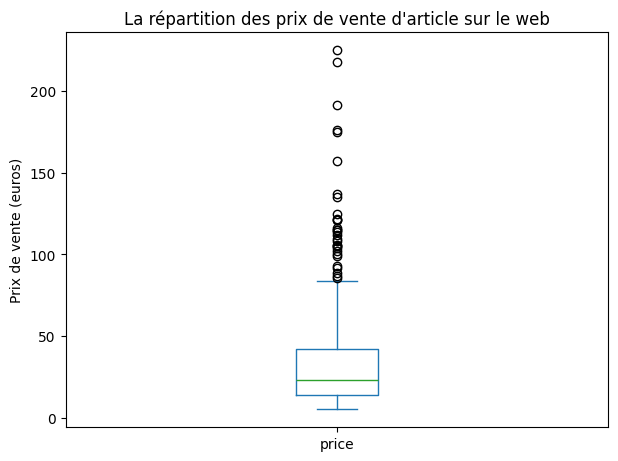

In [120]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
plt.figure(figsize = (7,5))
erp_liaison_web["price"].plot(kind="box")
plt.ylabel("Prix de vente (euros)")
plt.title("La répartition des prix de vente d'article sur le web")
plt.subplots_adjust(top=0.9)

plt.savefig("box_price.png")

plt.show()

In [121]:
#Autre méthode avec plotly express
box_price = px.box(erp_liaison_web, y="price", title = "La répartition des prix de vente de chaque produit")
box_price.update_layout(yaxis_title_text="Prix de vente")
box_price.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [122]:
#Calculer la moyenne du prix
moyPrice = erp_liaison_web["price"].mean()
print("La moyenne du prix d'après Z-score est de {:.2f}".format(erp_liaison_web["price"].median()))

#Calculer l'écart-type du prix
stdPrice = erp_liaison_web["price"].std()
print("L'écart-type du prix est de {:.2f} (variation autour de la moyenne)".format(erp_liaison_web["price"].std()))

#Calculer le Z-score
erp_liaison_web["Z-score"] = erp_liaison_web["price"].apply(lambda x: (x - moyPrice)/stdPrice)


La moyenne du prix d'après Z-score est de 23.45
L'écart-type du prix est de 27.60 (variation autour de la moyenne)


In [123]:
#Quel est le seuil prix dont z-score est supérieur à 3?
seuil_outlier = min(erp_liaison_web.loc[erp_liaison_web["Z-score"]>3,"price"])
print("Le seuil de prix dont Z-score est supérieur à 3 est de {}. \nC'est le seuil d'outlier de la méthode statistique de Z-score.".format(seuil_outlier))


Le seuil de prix dont Z-score est supérieur à 3 est de 116.4. 
C'est le seuil d'outlier de la méthode statistique de Z-score.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [124]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
pd.DataFrame.describe(erp_liaison_web["price"])

,price
count,714.000000
mean,32.333683
std,27.596332
min,5.200000
25%,14.062500
50%,23.450000
75%,42.075000
max,225.000000


In [125]:
#Définissez un seuil pour les articles "outliers" en prix
ecart_interquartile = erp_liaison_web["price"].quantile(0.75) - erp_liaison_web["price"].quantile(0.25)
print("Le seuil d'outlier supérieur du prix de vente est de {} selon l'interval interquartile".format(round(erp_liaison_web["price"].quantile(0.75) + 1.5*ecart_interquartile, 2)))


Le seuil d'outlier supérieur du prix de vente est de 84.09 selon l'interval interquartile


In [126]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
erp_outliersup = erp_liaison_web[erp_liaison_web["price"]>120]["product_id"].count()
erp_partOutliers = erp_outliersup/erp_liaison_web["product_id"].count()*100
print("On décide de prendre 120 comme seuil des valeurs aberrantes. \nLe nombre d'outliers supérieur à 120 est de {sup}.".format(sup=erp_outliersup))
print("Le pourcentage d'outliers est de {}%".format(round(erp_partOutliers,2)))


On décide de prendre 120 comme seuil des valeurs aberrantes. 
Le nombre d'outliers supérieur à 120 est de 12.
Le pourcentage d'outliers est de 1.68%


In [127]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
erp_liaison_web.loc[erp_liaison_web["price"] >120, ["product_type", "post_title"]].value_counts()


product_type  post_title                                                                   
Champagne     Champagne Egly-Ouriet Grand Cru Millésimé 2008                                   1
              Champagne Gosset Célébris Vintage 2007                                           1
              Coteaux Champenois Egly-Ouriet Ambonnay Rouge 2016                               1
Cognac        Cognac Frapin Château de Fontpinot 1989 20 Ans d'Age                             1
              Cognac Frapin VIP XO                                                             1
Vin           Camille Giroud Clos de Vougeot 2016                                              1
              David Duband Charmes-Chambertin Grand Cru 2014                                   1
              Domaine Des Croix Corton Charlemagne Grand Cru 2016                              1
              Domaine Weinbach Gewurztraminer Grand Cru Furstentum SGN 2010 1/2                1
              Domaine des Comtes Lafon Volnay 1er Cru Champans 2016                            1
              Domaine des Comtes Lafon Volnay 1er Cru Santenots du Milieu 2016                 1
Whisky        Wemyss Malts Single Cask Scotch Whisky Choc 'n' Nut Pretzel 2001 Bunnahabhain    1
Name: count, dtype: int64

Les produits dont le prix est supérieur à 120 sont justifiables (sans erreur) d'après mes recherches sur Internet. Ces montants peuvent être dus à la difficulté liée à la durée du processus, à la récolte, à la conservation, etc.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [128]:
##############################
# Calculer le CA du site web #
##############################

#Créez une colonne calculant le CA par article
erp_liaison_web["CA_article"] = erp_liaison_web["price"]*erp_liaison_web["total_sales"]

#Calculez la somme de la colonne "ca_par_article"
print("Le CA du site web est de {} euros".format(round(erp_liaison_web["CA_article"].sum(),2)))
#Ce résultat correspond au chiffre d'affaire du site web


Le CA du site web est de 143680.1 euros


In [129]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
erp_liaison_web = erp_liaison_web.sort_values(by="CA_article", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
erp_liaison_web = erp_liaison_web.reset_index(drop=True)

#Afficher les 20 premiers articles en CA
erp_liaison_web[["product_id", "post_title","CA_article"]].head(20)


print("La moyenne du CA est de {moy} et son écart-type est de {std}".format(moy = round(erp_liaison_web["CA_article"].mean(),2), std = round(erp_liaison_web["CA_article"].std(),2)))


La moyenne du CA est de 201.23 et son écart-type est de 153.76


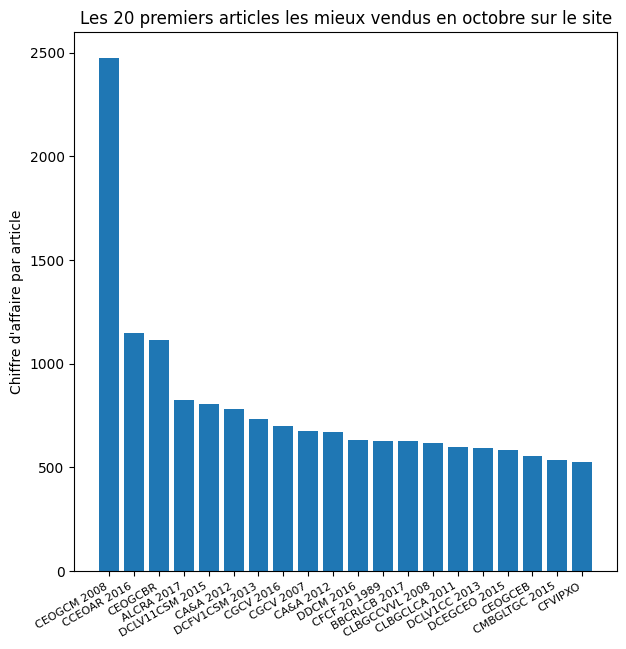

In [130]:
#Graphique en barre des 20 premiers articles avec plotly express

noms=["CEOGCM 2008", "CCEOAR 2016", "CEOGCBR", "ALCRA 2017", "DCLV11CSM 2015", "CA&A 2012",
      "DCFV1CSM 2013", "CGCV 2016", "CGCV 2007", "CA&A 2012", "DDCM 2016", "CFCF 20 1989",
      "BBCRLCB 2017", "CLBGCCVVL 2008", "CLBGCLCA 2011", "DCLV1CC 2013",
       "DCEGCEO 2015", "CEOGCEB", "CMBGLTGC 2015", "CFVIPXO"]

plt.figure(figsize=(7,7))
plt.bar(erp_liaison_web["post_title"].head(20), erp_liaison_web["CA_article"].head(20))
plt.title("Les 20 premiers articles les mieux vendus en octobre sur le site")
#plt.xticks(rotation = 90)
plt.xticks(ticks=np.arange(20), labels=noms, rotation=30, ha = "right", fontsize = 8)
plt.ylabel("Chiffre d'affaire par article")

#plt.savefig("bar_CA.png")
plt.show()

In [131]:
#############################
# Calculer le 20 / 80 en CA #
#############################

part = 80
#Créer une colonne calculant la part du CA de la ligne dans le dataset
erp_liaison_web["%CA_article"] = round(erp_liaison_web["CA_article"]/erp_liaison_web["CA_article"].sum()*100, 2)

erp_liaison_web = erp_liaison_web.sort_values(by="%CA_article", ascending=False)
erp_liaison_web = erp_liaison_web.reset_index(drop=True)  #Réinitialiser l'index du dataset par un reset_index

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
erp_liaison_web["%CA_cumul"] = erp_liaison_web["%CA_article"].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
print("Le nombre d'articles représentant 80% du CA est de {}.".format(erp_liaison_web.loc[erp_liaison_web["%CA_cumul"]<=part,"product_id"].count()))

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
prop_80CAweb = round(erp_liaison_web.loc[erp_liaison_web["%CA_cumul"]<=part,"id_web"].count()/erp_liaison_web.loc[erp_liaison_web["id_web"].notna(),"id_web"].count()*100,2)
print("La proportion d'article représentant 80% du CA est de {}% sur l'ensemble du site".format(prop_80CAweb))



Le nombre d'articles représentant 80% du CA est de 433.
La proportion d'article représentant 80% du CA est de 60.64% sur l'ensemble du site


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [132]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
erp_liaison_web["sale_quantity"] = erp_liaison_web["total_sales"]
erp_liaison_web = erp_liaison_web.sort_values(by="sale_quantity", ascending=False)

#Réinitialiser l'index du dataset par un reset_index
erp_liaison_web = erp_liaison_web.reset_index(drop=True)

#Afficher les 20 premier articles en quantité
erp_liaison_web[["product_id", "post_title","total_sales", "sale_quantity", "price", "stock_quantity"]].head(20)


print("La vente totale est de {sum}, la moyenne des ventes est de {moy}, et son écart-type est de {std}.".format(sum = round(erp_liaison_web["sale_quantity"].sum(),2), moy = round(erp_liaison_web["sale_quantity"].mean(),2), std = round(erp_liaison_web["sale_quantity"].std(),2)))

La vente totale est de 5751.0, la moyenne des ventes est de 8.05, et son écart-type est de 4.16.


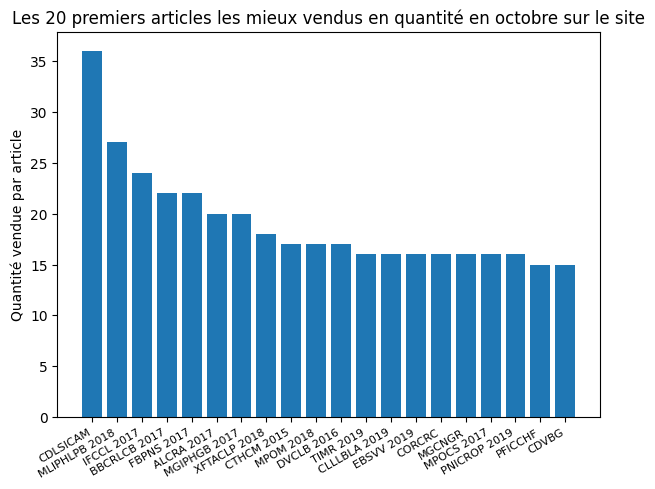

In [133]:
#Graphique en barre des 20 premiers articles avec plotly express
noms =["CDLSICAM", "MLIPHLPB 2018", "IFCCL 2017", "BBCRLCB 2017", "FBPNS 2017", "ALCRA 2017", "MGIPHGB 2017", "XFTACLP 2018",
      "CTHCM 2015", "MPOM 2018", "DVCLB 2016", "TIMR 2019", "CLLLBLA 2019", "EBSVV 2019", "CORCRC", "MGCNGR",
      "MPOCS 2017", "PNICROP 2019", "PFICCHF", "CDVBG"]

plt.figure(figsize = (7, 5))
plt.bar(erp_liaison_web["post_title"].head(20), erp_liaison_web["sale_quantity"].head(20))
plt.title("Les 20 premiers articles les mieux vendus en quantité en octobre sur le site")
#plt.xticks(rotation = 90)
plt.xticks(ticks=np.arange(20), labels=noms, rotation=30, ha = "right", fontsize = 8)
plt.ylabel("Quantité vendue par article")

#plt.savefig("bar_saleQt.png")
plt.show()



In [134]:
#############################
# Calculer le 20 / 80 en CA #
#############################

part = 80
#Créer une colonne calculant la part en quantité de la ligne dans le dataset
erp_liaison_web["%quantity_online"] = round(erp_liaison_web["sale_quantity"]/erp_liaison_web["sale_quantity"].sum()*100,2)
erp_liaison_web = erp_liaison_web.sort_values(by="%quantity_online", ascending=False)

erp_liaison_web = erp_liaison_web.reset_index(drop=True)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
erp_liaison_web["%quantity_online_cumul"] = erp_liaison_web["%quantity_online"].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
print("Le nombre d'articles représentant 80% du CA est de {}.".format(erp_liaison_web.loc[erp_liaison_web["%quantity_online_cumul"]<=part,"product_id"].count()))

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
prop_80qtweb = round(erp_liaison_web.loc[erp_liaison_web["%quantity_online_cumul"]<=part,"id_web"].count()/erp_liaison_web.loc[erp_liaison_web["id_web"].notna(),"id_web"].count()*100,2)
print("La proportion d'article représentant 80% de quantité est de {}% sur l'ensemble du site".format(prop_80qtweb))


Le nombre d'articles représentant 80% du CA est de 432.
La proportion d'article représentant 80% de quantité est de 60.5% sur l'ensemble du site


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [135]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Création de la colonne Rotation de stock
erp_liaison_web["Rotation_stock"] = erp_liaison_web["stock_quantity"]/round(erp_liaison_web["sale_quantity"])

#Remplacement des "inf" par 0
erp_liaison_web["Rotation_stock"] = round(erp_liaison_web["Rotation_stock"].replace([np.inf], 0),2)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
erp_liaison_web = erp_liaison_web.sort_values(by="Rotation_stock", ascending=False)

erp_liaison_web.reset_index(drop=True)  #Réinitialiser l'index du dataset par un reset

#Afficher les 20 premiers articles en nombre de mois de stock
erp_liaison_web[["product_id","post_title", "Rotation_stock", "product_type"]].sort_values(by="Rotation_stock", ascending = False).head(20)

,product_id,post_title,Rotation_stock,product_type
588,4142,Champagne Gosset Grand Millésime 2006,31.25,Champagne
556,6126,Champagne Gosset Célébris Vintage 2007,27.60,Champagne
641,4356,Champagne Egly-Ouriet Premier Cru Les Vignes d...,27.00,Champagne
558,4348,Champagne Egly-Ouriet Grand Cru Brut Tradition,25.00,Champagne
629,4148,Champagne Mailly Grand Cru Brut Rosé,23.67,Champagne
524,4357,Champagne Larmandier-Bernier Latitude,23.00,Champagne
609,4144,Champagne Gosset Grand Rosé,22.75,Champagne
502,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,22.67,Champagne
403,4350,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,20.71,Champagne
470,4150,Champagne Mailly Grand Cru Intemporelle 2010,20.50,Champagne


In [136]:
# Stats descriptives de Rotation_stock
print("Les mesures statistiques de rotation de stock sont les suivantes :\n{}".format(erp_liaison_web["Rotation_stock"].describe()))

Les mesures statistiques de rotation de stock sont les suivantes :
count    692.000000
mean       2.968497
std        3.465931
min        0.000000
25%        1.750000
50%        2.400000
75%        3.082500
max       31.250000
Name: Rotation_stock, dtype: float64


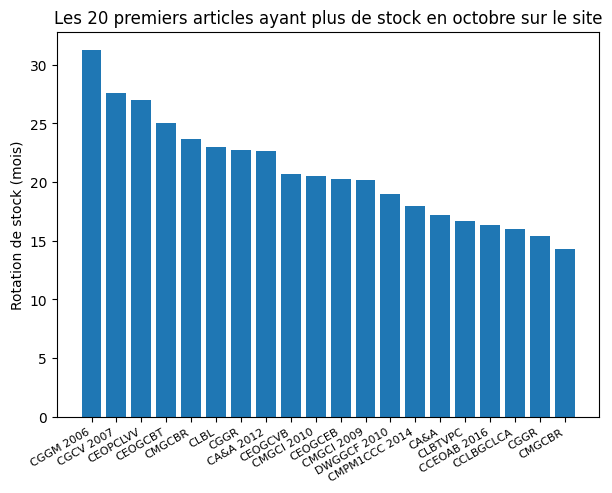

In [137]:
#Graphique en barre des 20 premiers des produits qui ont le plus de mois de stock
noms = ["CGGM 2006", "CGCV 2007", "CEOPCLVV", "CEOGCBT", "CMGCBR", "CLBL", "CGGR",
        "CA&A 2012", "CEOGCVB", "CMGCI 2010", "CEOGCEB", "CMGCI 2009", "DWGGCF 2010",
        "CMPM1CCC 2014", "CA&A", "CLBTVPC", "CCEOAB 2016", "CCLBGCLCA", "CGGR","CMGCBR"]

plt.figure(figsize=(7,5))
plt.bar(erp_liaison_web["post_title"].head(20), erp_liaison_web["Rotation_stock"].head(20))
plt.title("Les 20 premiers articles ayant plus de stock en octobre sur le site")
#plt.xticks(rotation = 90)
plt.xticks(ticks=np.arange(20), labels=noms, rotation=30, ha = "right", fontsize = 8)
plt.ylabel("Rotation de stock (mois)")

#plt.savefig("bar_rotation.png")
plt.show()

In [138]:
####################################
# Valorisation des stocks en euros #
####################################
#Création de la colonne Valorisation des stocks en euros
erp_liaison_web["stock_value"] = erp_liaison_web["stock_quantity"]*erp_liaison_web["purchase_price"]

#Calculer la somme de la colonne "Valorisation_stock_euros"
print("La valeur de stock est de {} euros".format(round(erp_liaison_web["stock_value"].sum(),2)))


La valeur de stock est de 277350.37 euros


In [139]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
sum_stock_quantity = erp_liaison_web["stock_quantity"].sum()

print("Le stock total est de {qt}.".format(qt=sum_stock_quantity))

Le stock total est de 16741.


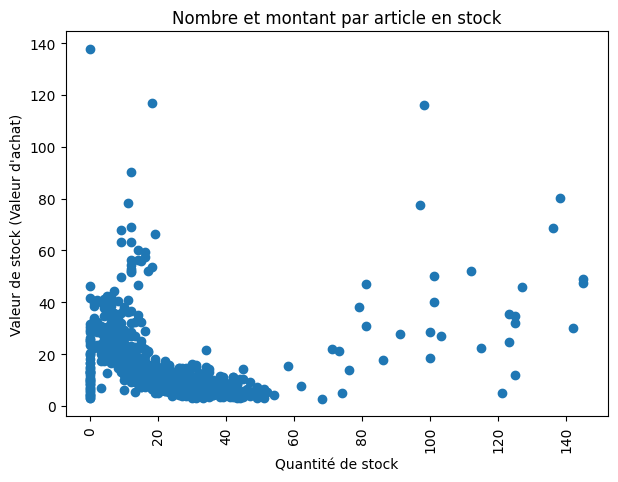

In [140]:
# Graphique étudiant la relation entre la valeur de stock et la quantité de stock
plt.figure(figsize= (7,5))
plt.scatter(erp_liaison_web["stock_quantity"], erp_liaison_web["purchase_price"])
plt.title("Nombre et montant par article en stock")
plt.xticks(rotation = 90)
#plt.xticks(ticks=np.arange(20), labels=noms, rotation=90)
plt.ylabel("Valeur de stock (Valeur d'achat)")
plt.xlabel("Quantité de stock")

#plt.savefig("bar_Stock.png")
plt.show()

On voit, d'après le graphique, que la plupart des valeurs de stock ne dépassent pas 70 euros et que peu d'articles sont stockés en grande quantité.

Si l'on s'intéresse aux articles dont la quantité en stock se situe dans l'intervalle [0 ; 60], on remarque que plus un article est cher, moins il est stocké. Cependant, au-delà de cet intervalle, cette tendance est moins marquée.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [141]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
TVA = 0.2

erp_liaison_web["prix_HT"] = erp_liaison_web["price"]/(1+TVA)
erp_liaison_web["purchase_HT"] = erp_liaison_web["purchase_price"]/(1+TVA)

#Création de la colonne Taux de marge
erp_liaison_web["Taux_marge"] = round((erp_liaison_web["prix_HT"] - erp_liaison_web["purchase_HT"])/erp_liaison_web["purchase_HT"]*100,2)

#Afficher le prix minimum de la colonne "taux_marge"
min_txMarge = erp_liaison_web["Taux_marge"].min()

#Afficher le prix maximum de la colonne "taux_marge"
max_txMarge = erp_liaison_web["Taux_marge"].max()

print("Le taux de marge le plus haut est de {max_marge}% et le plus bas est de {min_marge}%".format(max_marge = max_txMarge, min_marge = min_txMarge))


Le taux de marge le plus haut est de 129.69% et le plus bas est de -83.67%


In [142]:
#Affichage de la ligne avec un taux de marge inférieur à 0
erp_liaison_web.loc[erp_liaison_web["Taux_marge"]<0, ["product_id", "post_title","price", "purchase_price","Taux_marge"]]

,product_id,post_title,price,purchase_price,Taux_marge
713,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,-83.67


Ce produit possède un taux de marge qui est négatif, alors que cela ne me semble pas logique. Donc, on a supposé ici qu'il y a une erreur humaine qui a trompé de l'emplacement de point de décimal. Ainsi, on va le corriger en "price" = 126.5 pour la suite.

In [143]:
#création d'un dataframe avec les taux positifs

erp_liaison_web.loc[erp_liaison_web["prix_HT"]<erp_liaison_web["purchase_HT"], "price"] = 126.5

erp_liaison_web["prix_HT"] = erp_liaison_web["price"]/(1+TVA)
erp_liaison_web["taux_marge"] = round((erp_liaison_web["prix_HT"] - erp_liaison_web["purchase_HT"])/erp_liaison_web["purchase_HT"]*100,2)

#Afficher le prix minimum de la colonne "taux_marge"
min_txMarge = erp_liaison_web["taux_marge"].min()

#Afficher le prix maximum de la colonne "taux_marge"
max_txMarge = erp_liaison_web["taux_marge"].max()

print("Après la correction, le taux de marge le plus haut est de {max_marge}% et le plus bas est de {min_marge}%".format(max_marge = max_txMarge, min_marge = min_txMarge))


Après la correction, le taux de marge le plus haut est de 129.69% et le plus bas est de 55.4%


Ensuite, on peut étudier le taux de marge en fonction du type de produit.

In [144]:
#création d'un dataframe avec le taux de marge moyen par type de produit
erp_liaison_web.loc[erp_liaison_web["product_type"].isna(), "product_type"]="Inconnu"
txMargeMoyen_type = erp_liaison_web.groupby("product_type")["taux_marge"].mean()
df_txMargeMoyen_type = txMargeMoyen_type.sort_values(ascending=False)

df_txMargeMoyen_type = pd.DataFrame(df_txMargeMoyen_type).reset_index()
df_txMargeMoyen_type.columns = ["Type_produit","Taux_marge"]
df_txMargeMoyen_type


,Type_produit,Taux_marge
0,Cognac,118.777500
1,Whisky,118.088571
2,Gin,109.790000
3,Vin,93.795365
4,Inconnu,87.970000
5,Champagne,67.778929
6,Huile d'olive,60.070000


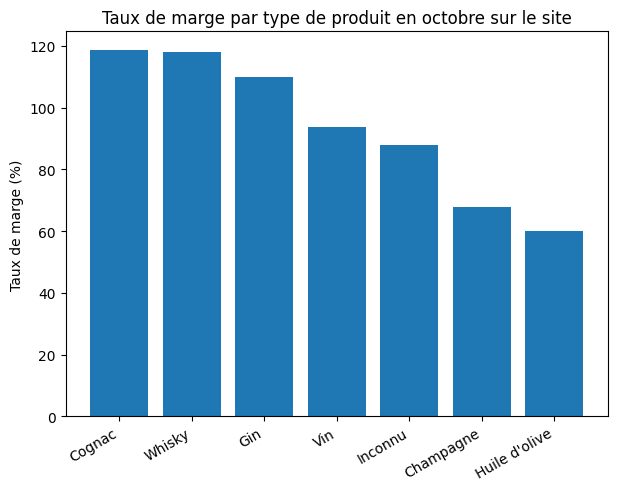

In [145]:
#Affichage dans un graphique du taux de marge par type de produit

plt.figure(figsize=(7, 5))
plt.bar(df_txMargeMoyen_type["Type_produit"], df_txMargeMoyen_type["Taux_marge"])
plt.title("Taux de marge par type de produit en octobre sur le site")
plt.xticks(rotation = 30, ha = "right")
plt.ylabel("Taux de marge (%)")
#plt.savefig("TxMarge.png")

plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

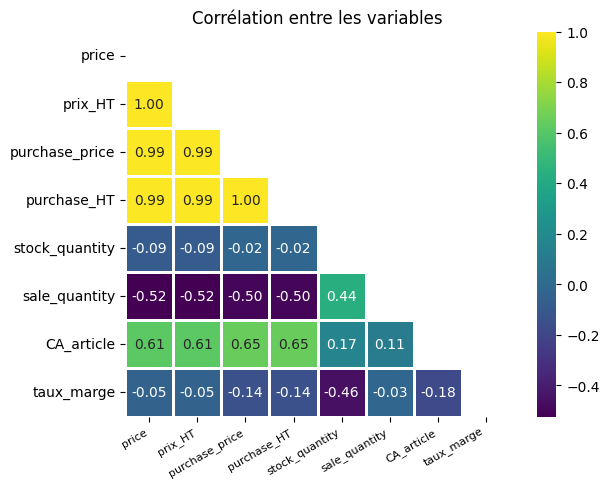

In [146]:
############################
# Analyse des correlations #
############################
#Importation de Seaborn

#Création d'un heatmap de correlation avec les variables stock, sales et price
plt.figure(figsize = (7,5))
sns.heatmap(erp_liaison_web[["price", "prix_HT", "purchase_price", "purchase_HT", "stock_quantity", "sale_quantity",  "CA_article", "taux_marge"]].corr(), annot=True, cmap="viridis", fmt=".2f", linewidths=1, square=True, mask=np.triu(erp_liaison_web[["price", "prix_HT", "purchase_price", "purchase_HT","stock_quantity", "sale_quantity", "CA_article", "taux_marge"]].corr()))
plt.title("Corrélation entre les variables")
plt.xticks(rotation = 30, ha = "right", fontsize = 8)
#plt.savefig("Correlation.png")

plt.show()


D'après ce graphique de corrélation linéaire, on peut constater plusieurs relations fortes entre les prix.

Le prix de vente et le prix de vente hors taxe sont différenciés par une simple valeur fixe, la TVA, ce qui explique leur corrélation de 100 %. Il en est de même pour les prix d'achat et prix d'achat hors taxe.

On observe également une forte corrélation entre les prix de vente et les prix d'achat (99 %), car, dans la plupart des cas, le prix de vente est fixé en fonction d’un ratio de rentabilité. Cela signifie que si le prix d'achat augmente, le prix de vente augmentera également.

Ces prix sont aussi corrélés positivement avec le chiffre d’affaires par article à plus de 60 %. En d'autres termes, si les prix de vente augmentent, le chiffre d’affaires augmentera proportionnellement.

Ensuite, on remarque que les relations entre la quantité de stock et les prix sont fortement corrélées négativement. Autrement dit, si le stock diminue, les prix augmentent.

Enfin, en observant la corrélation du taux de marge, on constate que seul le nombre de stocks présente une relation linéaire forte avec ce dernier (-46 %). Cela signifie que si le stock diminue, le taux de marge augmentera proportionnellement.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [147]:
#Selectionner les colonnes nécessaires
erp_liaison_web_select = erp_liaison_web[["product_id","onsale_web", "id_web", "tax_status",
                                          "product_type", "post_name", "price", "stock_quantity", "total_sales",
                                          "purchase_price", "CA_article", "%CA_article",
                                          "%CA_cumul", "%quantity_online", "%quantity_online_cumul",
                                         "Rotation_stock", "stock_value", "prix_HT", "purchase_HT", "taux_marge"]]


#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.

from os import write
erp_liaison_web_select.to_excel("erp_liaison_web.xlsx")
print("Exporté le fichier en excel !")


Exporté le fichier en excel !
